In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch
import sys
sys.path.append('.')
from model.gnn import GNN
from training.inference import inference

In [3]:
pred, actual, mae_per_step = inference(timestep=0)

lat = np.load('data/lat.npy')
lon = np.load('data/lon.npy')

n_lat = 129
n_lon = 121

var_names = ['u10', 'v10', 'sp', 't850', 't500', 'z850', 'z500']

In [4]:
def to_grid(arr):
    return arr.reshape(n_lat, n_lon)

lat_grid = lat.reshape(n_lat, n_lon)
lon_grid = lon.reshape(n_lat, n_lon)

c:\Users\MSI 1\AppData\Local\Programs\Python\Python310\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\MSI 1\AppData\Local\Programs\Python\Python310\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


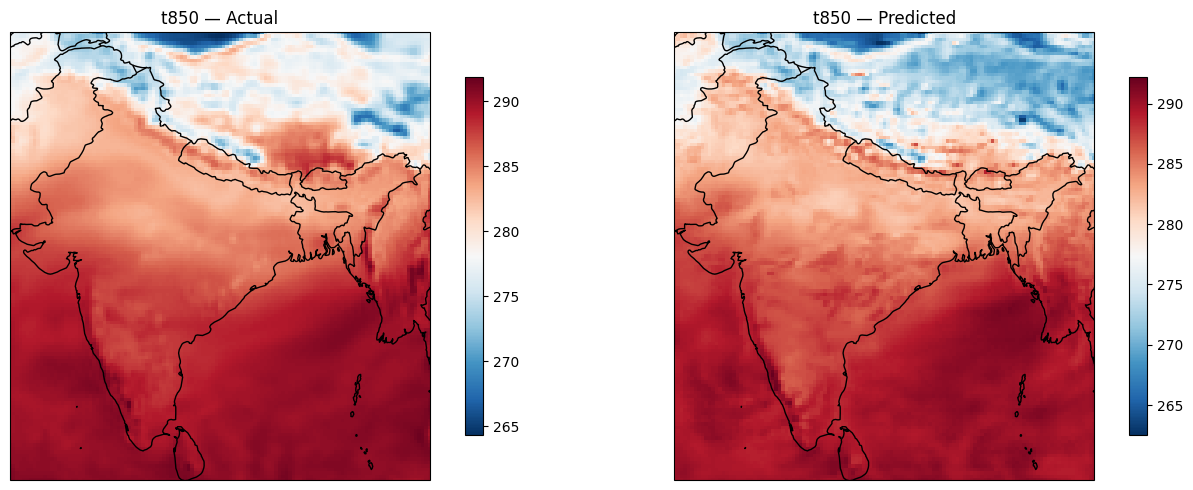

In [5]:
var_idx = 3  # t850
var_name = var_names[var_idx]

pred_grid = to_grid(pred[:, var_idx])
actual_grid = to_grid(actual[:, var_idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                          subplot_kw={'projection': ccrs.PlateCarree()})

for ax, data, title in zip(axes, 
                            [actual_grid, pred_grid], 
                            [f'{var_name} — Actual', f'{var_name} — Predicted']):
    ax.set_extent([68, 98, 6, 38], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    im = ax.pcolormesh(lon_grid, lat_grid, data, 
                        transform=ccrs.PlateCarree(), cmap='RdBu_r')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('plots/t850_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

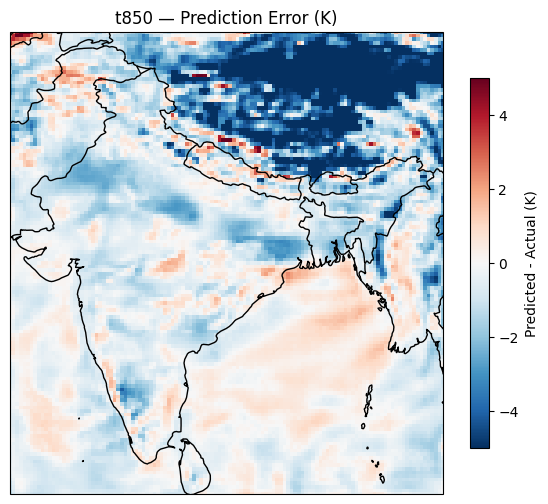

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6),
                        subplot_kw={'projection': ccrs.PlateCarree()})

error_grid = pred_grid - actual_grid

ax.set_extent([68, 98, 6, 38], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
im = ax.pcolormesh(lon_grid, lat_grid, error_grid,
                    transform=ccrs.PlateCarree(), 
                    cmap='RdBu_r', vmin=-5, vmax=5)
ax.set_title(f'{var_name} — Prediction Error (K)')
plt.colorbar(im, ax=ax, shrink=0.8, label='Predicted - Actual (K)')

plt.savefig('plots/t850_error.png', dpi=150, bbox_inches='tight')
plt.show()

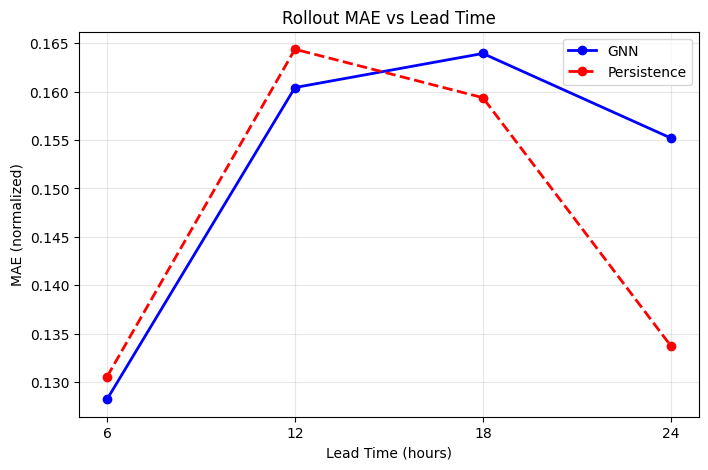

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

lead_times = [(k+1)*6 for k in range(len(mae_per_step))]
persistence = [0.130564, 0.164381, 0.159375, 0.133760]

ax.plot(lead_times, mae_per_step, 'b-o', label='GNN', linewidth=2, markersize=6)
ax.plot(lead_times, persistence, 'r--o', label='Persistence', linewidth=2, markersize=6)

ax.set_xlabel('Lead Time (hours)')
ax.set_ylabel('MAE (normalized)')
ax.set_title('Rollout MAE vs Lead Time')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(lead_times)

plt.savefig('plots/rollout_mae.png', dpi=150, bbox_inches='tight')
plt.show()

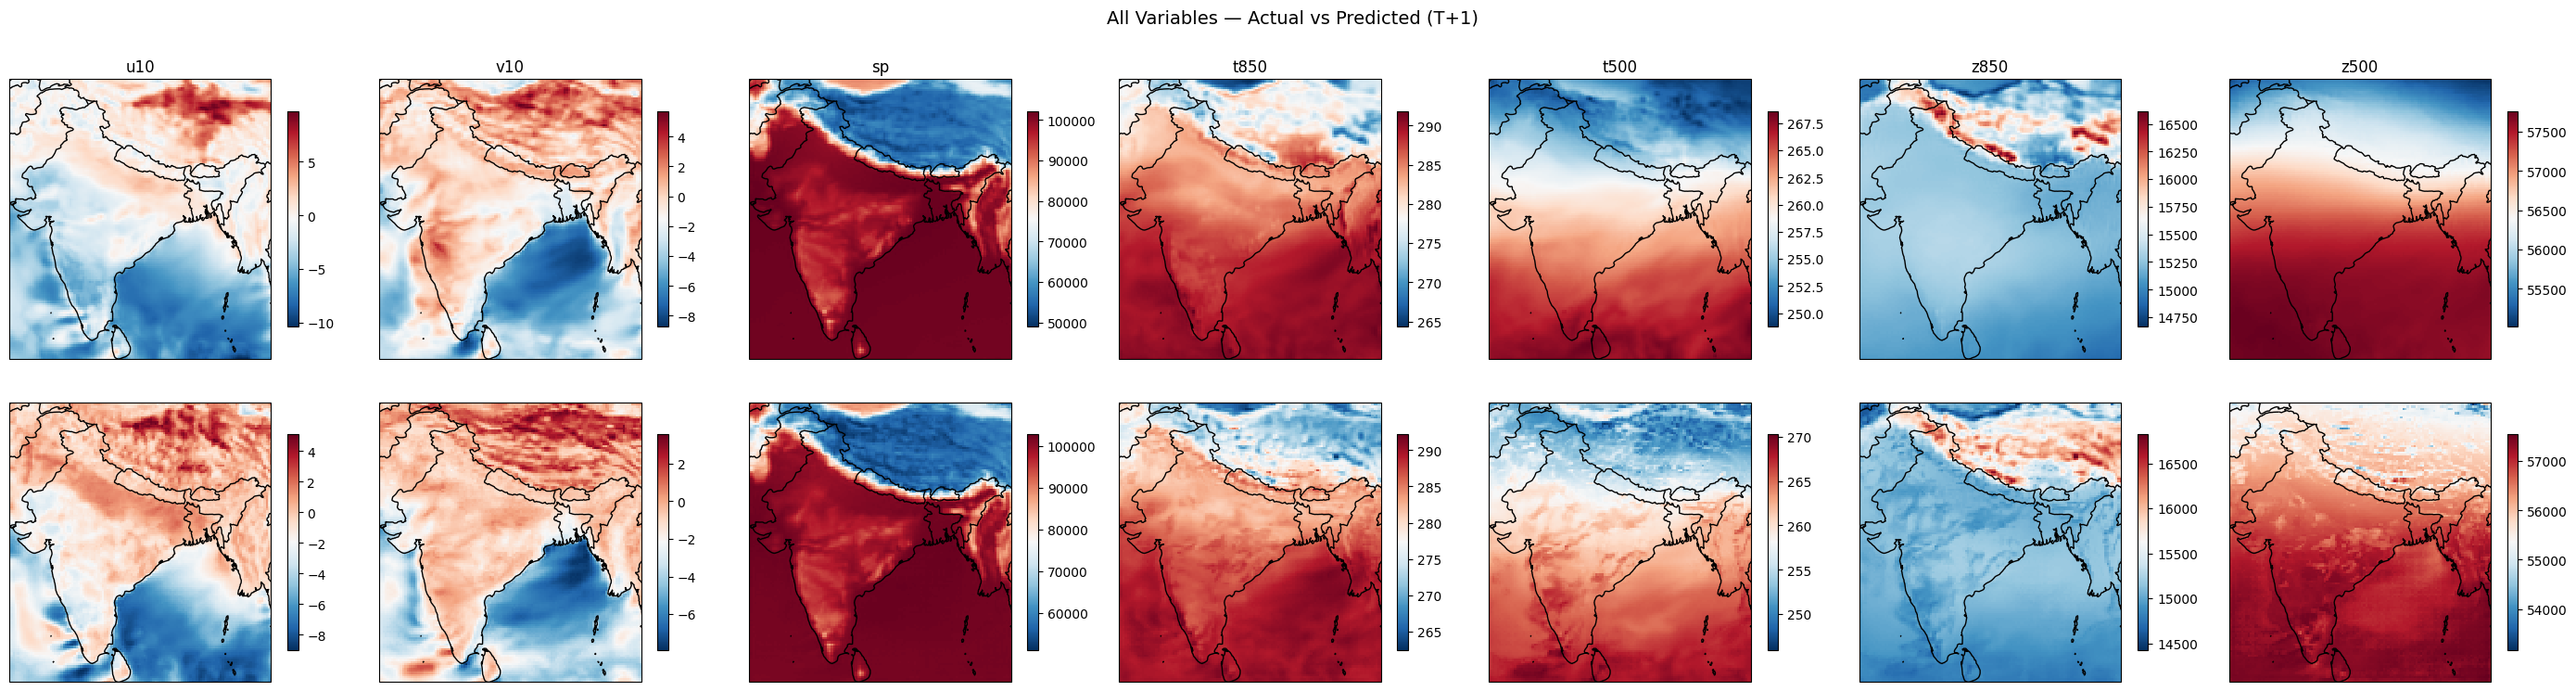

In [8]:
fig, axes = plt.subplots(2, 7, figsize=(28, 8),
                          subplot_kw={'projection': ccrs.PlateCarree()})

for i, name in enumerate(var_names):
    pred_grid = to_grid(pred[:, i])
    actual_grid = to_grid(actual[:, i])
    
    for j, (data, row_title) in enumerate(zip([actual_grid, pred_grid], ['Actual', 'Predicted'])):
        ax = axes[j, i]
        ax.set_extent([68, 98, 6, 38], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS)
        im = ax.pcolormesh(lon_grid, lat_grid, data,
                           transform=ccrs.PlateCarree(), cmap='RdBu_r')
        if j == 0:
            ax.set_title(name)
        if i == 0:
            ax.set_ylabel(row_title)
        plt.colorbar(im, ax=ax, shrink=0.6)

plt.suptitle('All Variables — Actual vs Predicted (T+1)', fontsize=14)
plt.tight_layout()
plt.savefig('plots/all_variables.png', dpi=150, bbox_inches='tight')
plt.show()